<a href="https://colab.research.google.com/github/stacykeago/predictive-data-analytics/blob/main/part_2_set_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SET EXERCISE DETAILS:

3. Load the dataset into your workspace, using the following link:
https://drive.google.com/file/d/1wJj-Cy5f5KmVEmD8KQH6ncup2JHNGSxn/view?usp=sharing
Choose an appropriate regression model, train and evaluate it.
Identify the underlying trends in the data.

# Exploratory Data Analysis

## Import the libraries

In [6]:
import numpy as np # for linear algebra
import pandas as pd # for data processing
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for statistical data visualization
from sklearn.preprocessing import LabelEncoder # the libraries for label encoding
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Upload the datasets

In [7]:
# Extract the file ID from your link: 1wJj-Cy5f5KmVEmD8KQH6ncup2JHNGSxn
url = 'https://drive.google.com/uc?export=download&id=1wJj-Cy5f5KmVEmD8KQH6ncup2JHNGSxn'

data = pd.read_csv(url)
print(data.head(10))

          t         f(t)
0  0.479155     0.472010
1 -1.021461    37.567432
2 -4.467154  1507.309054
3  1.130598     5.036163
4 -1.007833    36.566910
5  2.189355     8.786154
6  2.623489     6.818684
7  1.867776     8.895407
8  2.333211     8.346151
9  0.066760     0.543782


## Check for the rows and columns

In [8]:
# Print number of rows and columns
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")

Rows: 1000, Columns: 2


## Check the data types

In [9]:
data.dtypes

,0
t,float64
f(t),float64


## check for missing values

### check for symbols in the data

In [10]:
for col in data.columns:
    count = data[col].astype(str).str.contains(r'[^a-zA-Z0-9\s.]', na=False).sum()
    if count > 0:
        print(f"Column '{col}' has {count} rows with symbols.")

Column 't' has 493 rows with symbols.


## check for anomalies

In [13]:
url = 'https://drive.google.com/uc?export=download&id=1wJj-Cy5f5KmVEmD8KQH6ncup2JHNGSxn'
data = pd.read_csv(url)

print("--- Missing Values ---")
print(data.isnull().sum())

print("\n--- Duplicates ---")
print(data.duplicated().sum())

print("\n--- Outliers ---")
num_data = data.select_dtypes(include=['number'])
z_scores = (num_data - num_data.mean()) / num_data.std()
print((z_scores.abs() > 3).sum())

--- Missing Values ---
t       0
f(t)    0
dtype: int64

--- Duplicates ---
0

--- Outliers ---
t        0
f(t)    26
dtype: int64


## check for outliers

In [14]:
import pandas as pd

# Load your data first (replace with your variable)
# data = pd.read_csv('your_file.csv')

# Get only numeric columns
num_data = data.select_dtypes(include=['number'])

# 1. Z-Score Method (Outliers where |Z| > 3)
z_scores = (num_data - num_data.mean()) / num_data.std()
z_outliers = data[(z_scores.abs() > 3).any(axis=1)]

# 2. IQR Method (Outliers outside 1.5 * IQR)
Q1 = num_data.quantile(0.25)
Q3 = num_data.quantile(0.75)
IQR = Q3 - Q1
iqr_outliers = data[((num_data < (Q1 - 1.5 * IQR)) | (num_data > (Q3 + 1.5 * IQR))).any(axis=1)]

print(f"Rows with Z-score outliers: {len(z_outliers)}")
print(f"Rows with IQR outliers: {len(iqr_outliers)}")

# To view them, just look at z_outliers or iqr_outliers

Rows with Z-score outliers: 26
Rows with IQR outliers: 152


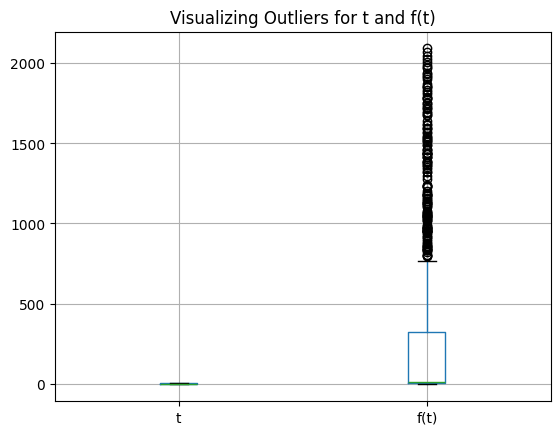

In [16]:
import matplotlib.pyplot as plt

# Boxplot for t and f(t) to visually inspect outliers
data[['t', 'f(t)']].boxplot()
plt.title("Visualizing Outliers for t and f(t)")

# Save the plot since plt.show() won't display an interactive window here
plt.savefig('outliers_boxplot.png')

## Unique features

In [17]:
data.nunique()

,0
t,1000
f(t),1000


## Check for duplicates

In [18]:
#check for duplicates : Duplicates are noise to the data
np.sum(data.duplicated())

np.int64(0)

# Statistical analysis of the data

In [19]:
data.describe()

,t,f(t)
count,1000.000000,1000.000000
mean,0.029528,276.432619
std,2.912450,490.620460
min,-4.981509,0.000152
25%,-2.571579,3.796317
50%,0.050400,8.999929
75%,2.644340,320.386458
max,4.989894,2092.282079


## Check for skewness

In [21]:
print("\nSkewness of features:")
print(data[['t', 'f(t)']].skew())


Skewness of features:
t      -0.014747
f(t)    1.936648
dtype: float64


In [24]:
# Print unique values for each column to see if you even have classes
print(data['t'].value_counts())
print(data['f(t)'].value_counts())

t
 3.672993    1
 0.479155    1
-1.021461    1
-4.467154    1
 1.130598    1
            ..
 2.615462    1
 1.993996    1
-3.952100    1
 0.066760    1
 2.333211    1
Name: count, Length: 1000, dtype: int64
f(t)
0.040439       1
0.472010       1
37.567432      1
1507.309054    1
5.036163       1
              ..
6.870725       1
8.999784       1
1051.542589    1
0.543782       1
8.346151       1
Name: count, Length: 1000, dtype: int64


# Univariate analysis

--- Summary Statistics ---
                 t         f(t)
count  1000.000000  1000.000000
mean      0.029528   276.432619
std       2.912450   490.620460
min      -4.981509     0.000152
25%      -2.571579     3.796317
50%       0.050400     8.999929
75%       2.644340   320.386458
max       4.989894  2092.282079


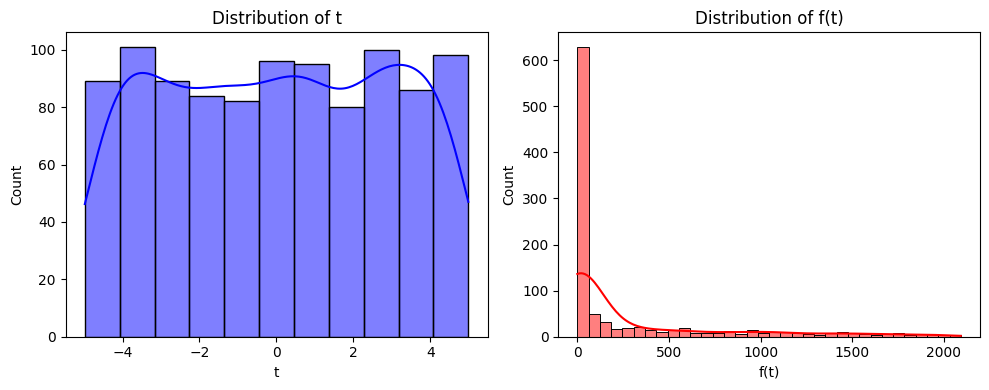

In [25]:
# 1. Summary Statistics
print("--- Summary Statistics ---")
print(data[['t', 'f(t)']].describe())

# 2. Distribution Plot for 't'
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(data['t'], kde=True, color='blue')
plt.title('Distribution of t')

# 3. Distribution Plot for 'f(t)'
plt.subplot(1, 2, 2)
sns.histplot(data['f(t)'], kde=True, color='red')
plt.title('Distribution of f(t)')

plt.tight_layout()
plt.savefig('univariate_distribution.png')

# Bivariate Analysis

--- Correlation Matrix ---
             t      f(t)
t     1.000000 -0.750757
f(t) -0.750757  1.000000


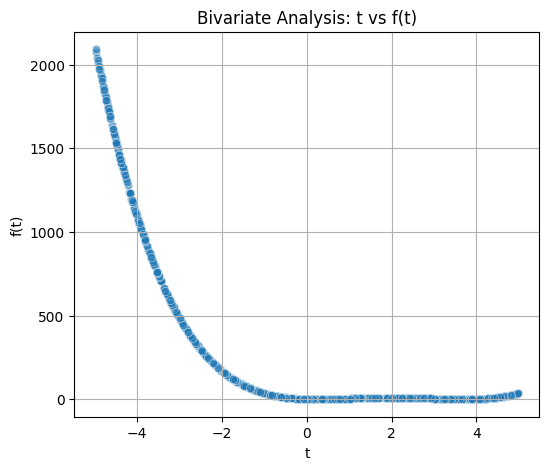

In [26]:
# 1. Correlation Coefficient
print("--- Correlation Matrix ---")
print(data[['t', 'f(t)']].corr())

# 2. Scatter Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='t', y='f(t)', data=data, alpha=0.6)
plt.title('Bivariate Analysis: t vs f(t)')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.grid(True)

plt.savefig('bivariate_scatter.png')

# Multivariate analsis



In [27]:
print(data[['t', 'f(t)']].corr())

             t      f(t)
t     1.000000 -0.750757
f(t) -0.750757  1.000000


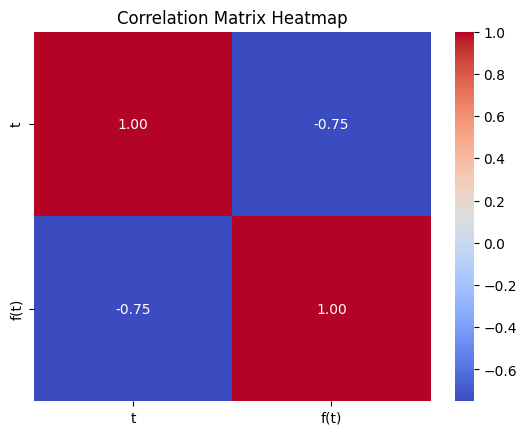

In [28]:
sns.heatmap(data[['t', 'f(t)']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.savefig('correlation_matrix.png')

# Gini impurity

In [ ]:
p0 = 0.5556
p1 = 0.4436

# 1. Gini Impurity
gini = 1 - (p0**2 + p1**2)

# 2. Entropy (base 2)
entropy = - (p0 * np.log2(p0) + p1 * np.log2(p1))

# 3. Misclassification Rate
misclassification_rate = 1 - max(p0, p1)

print(f"Gini Impurity:         {gini:.4f}")
print(f"Entropy:               {entropy:.4f}")
print(f"Misclassification Rate: {misclassification_rate:.4f}")

In [ ]:
# Data metrics from your dataframe
total_instances = 1374
n_0 = 764
n_1 = 610

# Calculate exact probabilities
p0 = n_0 / total_instances
p1 = n_1 / total_instances

# 1. Gini Impurity
gini = 1 - (p0**2 + p1**2)

# 2. Entropy
entropy = -(p0 * np.log2(p0) + p1 * np.log2(p1))

# 3. Misclassification Rates
rate_deterministic = 1 - max(p0, p1)
rate_stochastic = 2 * p0 * p1

# Print Results
print(f"--- Task 2 Calculation Outputs ---")
print(f"Probability P_0:         {p0:.6f}")
print(f"Probability P_1:         {p1:.6f}")
print(f"Gini Impurity:           {gini:.4f}")
print(f"Entropy:                 {entropy:.4f}")
print(f"Misclassification (Maj): {rate_deterministic:.4f}")
print(f"Misclassification (Rand):{rate_stochastic:.4f}")